# Generación de mapas predictivos
## Detección de cianobacteria en los lagos Atitlán y Amatitlán

Este notebook usa el mejor modelo del notebook 05, el **Random Forest**, para calcular la probabilidad de alta presencia de cianobacteria en cada píxel, reconstruye esas predicciones sobre la malla original de 10 metros y compara los mapas resultantes con los mapas de NDCI de la Parte I.

**Contenido:**
1. Carga del modelo y de los datos
2. Cálculo de probabilidades para cada observación (9.1)
3. Escala de probabilidad de cuatro niveles (9.4)
4. Reconstrucción espacial y mapas por lago (9.2, 9.3)
5. Comparación con los mapas de cianobacteria de la Parte I (9.5)
6. Zonas bien detectadas, falsos positivos y falsos negativos (9.6)
7. Regiones donde el modelo tiene mayor dificultad (9.7)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import joblib

np.random.seed(42)
Path('./data/figuras/predictivos').mkdir(parents=True, exist_ok=True)

## 1. Carga del modelo y de los datos

Se usa el dataset completo, no solo el conjunto de prueba, porque un mapa necesita todos los píxeles del lago para verse continuo. Como el modelo se entrenó con el 70 % de esos píxeles, se marca cuáles pertenecían al conjunto de prueba: **toda la cuantificación de errores se hace únicamente sobre esos píxeles no vistos**, mientras que los mapas de probabilidad se dibujan con todos para que no queden huecos.

In [2]:
modelo = joblib.load('./modelos/mejor_modelo.pkl')
modelo.n_jobs = -1

X = pd.read_parquet('./data/X_predictoras.parquet')
y = pd.read_parquet('./data/y_respuesta.parquet').squeeze()
meta = pd.read_parquet('./data/dataset_ml_con_respuesta.parquet',
                       columns=['lago', 'fecha', 'lon', 'lat', 'NDCI'])
meta['lago'] = meta['lago'].str.strip().str.lower()

idx_test = pd.read_parquet('./data/idx_test.parquet')['idx'].values
en_prueba = np.zeros(len(X), dtype=bool)
en_prueba[idx_test] = True

print(f'Dataset completo: {len(X):,} píxeles')
print(f'Píxeles del conjunto de prueba (no vistos en entrenamiento): {en_prueba.sum():,} '
      f'({100*en_prueba.mean():.1f}%)')
print(f'Clase 1 real: {y.sum():,} ({100*y.mean():.2f}%)')

Dataset completo: 13,514,711 píxeles
Píxeles del conjunto de prueba (no vistos en entrenamiento): 4,054,414 (30.0%)
Clase 1 real: 301,089 (2.23%)


## 2. Cálculo de probabilidades (9.1)

Se calcula para cada píxel la probabilidad de pertenecer a la clase 1, es decir, alta presencia de cianobacteria.

In [3]:
t0 = time.time()
prob = modelo.predict_proba(X)[:, 1]
print(f'Probabilidades calculadas para {len(prob):,} píxeles en {time.time()-t0:.0f} s')

mapa = meta.copy()
mapa['prob'] = prob.astype('float32')
mapa['y_real'] = y.values
mapa['en_prueba'] = en_prueba

print()
print('Estadísticas de la probabilidad predicha:')
print(mapa['prob'].describe().round(4).to_string())
print()
print('Probabilidad media por clase real:')
print(mapa.groupby('y_real')['prob'].agg(['mean', 'median', 'count']).round(4).to_string())

Probabilidades calculadas para 13,514,711 píxeles en 18 s

Estadísticas de la probabilidad predicha:


count    1.351471e+07
mean     4.850000e-02
std      1.701000e-01
min      0.000000e+00
25%      1.400000e-03
50%      4.300000e-03
75%      1.190000e-02
max      1.000000e+00

Probabilidad media por clase real:


          mean  median     count
y_real                          
0       0.0288  0.0042  13213622
1       0.9125  0.9838    301089


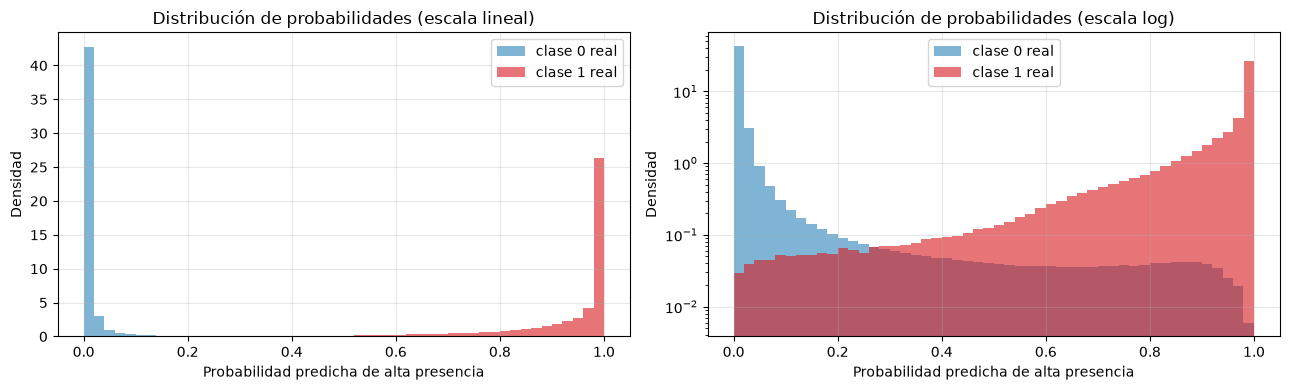

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, escala in zip(axes, ['lineal', 'log']):
    ax.hist(mapa.loc[mapa['y_real'] == 0, 'prob'], bins=50, alpha=0.6,
            label='clase 0 real', color='#2b83ba', density=True)
    ax.hist(mapa.loc[mapa['y_real'] == 1, 'prob'], bins=50, alpha=0.6,
            label='clase 1 real', color='#d7191c', density=True)
    if escala == 'log':
        ax.set_yscale('log')
    ax.set_xlabel('Probabilidad predicha de alta presencia')
    ax.set_ylabel('Densidad')
    ax.set_title(f'Distribución de probabilidades (escala {escala})')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Escala de probabilidad de cuatro niveles (9.4)

Se definen cuatro niveles con cortes en 0.25, 0.50 y 0.75:

| Nivel | Rango | Lectura operativa |
|---|---|---|
| Muy baja | 0.00 a 0.25 | agua sin indicios de floración |
| Baja | 0.25 a 0.50 | señal débil, no supera el umbral de decisión |
| Alta | 0.50 a 0.75 | el modelo clasifica el píxel como floración, con evidencia moderada |
| Muy alta | 0.75 a 1.00 | evidencia fuerte |

El corte central en 0.50 es el mismo umbral de decisión usado en el notebook 05, así que la frontera entre baja y alta coincide con la clasificación del modelo. Los cortes en 0.25 y 0.75 separan los casos dudosos de los claros: el notebook 05 mostró que con umbrales altos, entre 0.77 y 0.87, la Precision del Random Forest sube por encima de 0.68, de modo que el nivel muy alta corresponde aproximadamente al régimen de alta confianza y sirve para priorizar dónde verificar en campo.

In [5]:
NIVELES = [0.0, 0.25, 0.50, 0.75, 1.0]
ETIQUETAS = ['Muy baja\n(0-0.25)', 'Baja\n(0.25-0.5)', 'Alta\n(0.5-0.75)', 'Muy alta\n(0.75-1)']
COLORES = ['#2c7bb6', '#abd9e9', '#fdae61', '#d7191c']
cmap_prob = ListedColormap(COLORES)
norm_prob = BoundaryNorm(NIVELES, cmap_prob.N)

mapa['nivel'] = pd.cut(mapa['prob'], bins=NIVELES, labels=['Muy baja', 'Baja', 'Alta', 'Muy alta'],
                       include_lowest=True)

tabla_niveles = pd.crosstab(mapa['lago'], mapa['nivel'], normalize='index') * 100
print('Porcentaje de píxeles en cada nivel, por lago:')
print(tabla_niveles.round(2).to_string())
print()
print('Conteo global por nivel:')
print(mapa['nivel'].value_counts().sort_index().to_string())

Porcentaje de píxeles en cada nivel, por lago:
nivel      Muy baja  Baja  Alta  Muy alta
lago                                     
amatitlan     82.66  2.96  2.17     12.21
atitlan       96.38  1.11  0.93      1.57

Conteo global por nivel:
nivel
Muy baja    12810769
Baja          179373
Alta          145477
Muy alta      379092


**Cómo se reparten los niveles.** El 94.79 % de los píxeles cae en el nivel muy baja, coherente con que solo el 2.23 % son floración real. La diferencia entre lagos es grande: en Amatitlán el 12.21 % de los píxeles queda en muy alta frente al 1.57 % en Atitlán, y el nivel muy baja pasa del 96.38 % en Atitlán al 82.66 % en Amatitlán.

Los niveles intermedios son los menos poblados (1.11 % y 0.93 % en Atitlán, 2.96 % y 2.17 % en Amatitlán). El modelo produce probabilidades polarizadas: para la mayoría de los píxeles está muy seguro y la zona de duda es estrecha. La probabilidad media es 0.0288 en los píxeles de clase 0 real y 0.9125 en los de clase 1, con medianas de 0.0042 y 0.9838.

## 4. Reconstrucción espacial y mapas por lago (9.2, 9.3)

Los píxeles vienen de una malla regular de 10 metros en coordenadas UTM 15N, así que se pueden volver a colocar en una matriz sin interpolar nada: basta convertir cada coordenada a índice de fila y columna. Las celdas sin dato quedan en blanco.

Se elige para cada lago la fecha con más floración observada y una fecha de comportamiento típico, de modo que los mapas muestren tanto el caso extremo como el habitual.

In [6]:
PASO = 10  # metros

limites = {}
for lago in ['atitlan', 'amatitlan']:
    s = meta[meta['lago'] == lago]
    limites[lago] = (s['lon'].min(), s['lat'].min(), s['lon'].max(), s['lat'].max())


def rasterizar(sub, valores, lago):
    """Coloca los valores en la malla de 10 m del lago. Devuelve la matriz y su extensión en km."""
    x0, y0, x1, y1 = limites[lago]
    ncol = int(round((x1 - x0) / PASO)) + 1
    nfil = int(round((y1 - y0) / PASO)) + 1
    grid = np.full((nfil, ncol), np.nan, dtype='float32')
    ix = np.rint((sub['lon'].values - x0) / PASO).astype(int)
    iy = np.rint((sub['lat'].values - y0) / PASO).astype(int)
    grid[iy, ix] = valores
    extent = [x0/1000, x1/1000, y0/1000, y1/1000]
    return grid, extent


prevalencia = (mapa.groupby(['lago', 'fecha'])['y_real'].mean() * 100).round(2)
fechas_sel = {}
for lago in ['atitlan', 'amatitlan']:
    p = prevalencia.loc[lago].sort_values(ascending=False)
    fechas_sel[lago] = [p.index[0], p.index[len(p)//2]]
    print(f'{lago.capitalize()}: fecha de mayor floración {p.index[0].date()} ({p.iloc[0]}% de clase 1), '
          f'fecha típica {p.index[len(p)//2].date()} ({p.iloc[len(p)//2]}% de clase 1)')

Atitlan: fecha de mayor floración 2025-01-18 (16.46% de clase 1), fecha típica 2026-07-22 (0.3% de clase 1)
Amatitlan: fecha de mayor floración 2026-06-19 (69.15% de clase 1), fecha típica 2025-04-28 (4.99% de clase 1)


In [7]:
cmap_err = ListedColormap(['#e8e8e8', '#fdae61', '#2c7bb6', '#d7191c'])
norm_err = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4)
NOMBRES_ERR = {0: 'Verdadero negativo', 1: 'Falso positivo', 2: 'Falso negativo', 3: 'Verdadero positivo'}


def figura_mapas(lago, fecha):
    sub = mapa[(mapa['lago'] == lago) & (mapa['fecha'] == fecha)]
    g_prob, ext = rasterizar(sub, sub['prob'].values, lago)
    g_ndci, _ = rasterizar(sub, sub['NDCI'].values, lago)
    g_real, _ = rasterizar(sub, sub['y_real'].values.astype(float), lago)

    # Mapa de errores solo con píxeles de prueba
    sub_t = sub[sub['en_prueba']]
    pred_t = (sub_t['prob'].values >= 0.5).astype(int)
    real_t = sub_t['y_real'].values
    codigo = np.where((real_t == 0) & (pred_t == 0), 0,
             np.where((real_t == 0) & (pred_t == 1), 1,
             np.where((real_t == 1) & (pred_t == 0), 2, 3)))
    g_err, _ = rasterizar(sub_t, codigo.astype(float), lago)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))

    im0 = axes[0].imshow(g_prob, origin='lower', extent=ext, cmap=cmap_prob, norm=norm_prob)
    axes[0].set_title('Probabilidad predicha')
    cb = fig.colorbar(im0, ax=axes[0], ticks=[0.125, 0.375, 0.625, 0.875], fraction=0.046)
    cb.ax.set_yticklabels(['Muy baja', 'Baja', 'Alta', 'Muy alta'], fontsize=8)

    im1 = axes[1].imshow(g_ndci, origin='lower', extent=ext, cmap='RdYlGn_r', vmin=-0.5, vmax=0.8)
    axes[1].set_title('NDCI observado (Parte I)')
    fig.colorbar(im1, ax=axes[1], fraction=0.046)

    axes[2].imshow(g_real, origin='lower', extent=ext, cmap=ListedColormap(['#e8e8e8', '#d7191c']),
                   vmin=0, vmax=1)
    axes[2].set_title('Clase real (NDCI >= 0.4)')

    axes[3].imshow(g_err, origin='lower', extent=ext, cmap=cmap_err, norm=norm_err)
    axes[3].set_title('Aciertos y errores (píxeles de prueba)')
    axes[3].legend(handles=[mpatches.Patch(color=c, label=NOMBRES_ERR[i])
                            for i, c in enumerate(cmap_err.colors)],
                   fontsize=7, loc='lower left')

    for ax in axes:
        ax.set_xlabel('X UTM (km)')
        ax.set_aspect('equal')
    axes[0].set_ylabel('Y UTM (km)')

    prev = 100 * sub['y_real'].mean()
    plt.suptitle(f'{lago.capitalize()}, {pd.Timestamp(fecha).date()} '
                 f'({len(sub):,} píxeles, {prev:.2f}% de clase 1 observada)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'./data/figuras/predictivos/mapa_{lago}_{pd.Timestamp(fecha).date()}.png', dpi=110)
    plt.show()

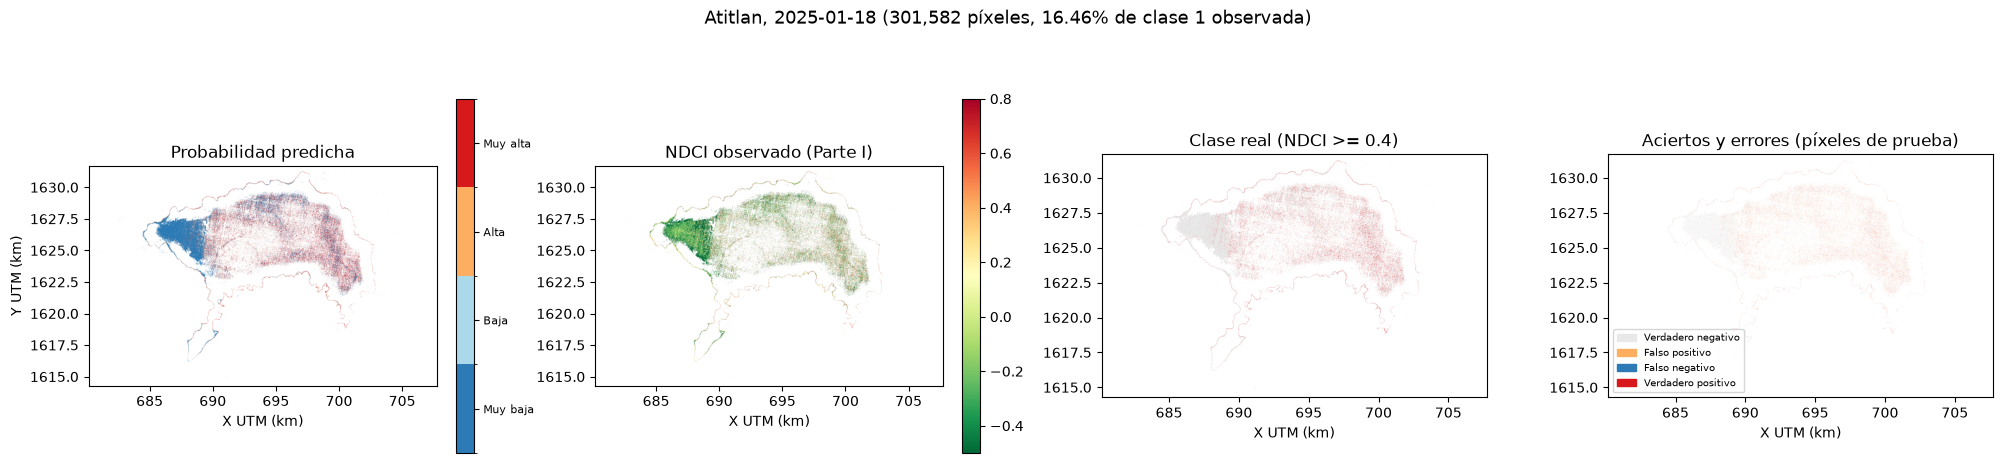

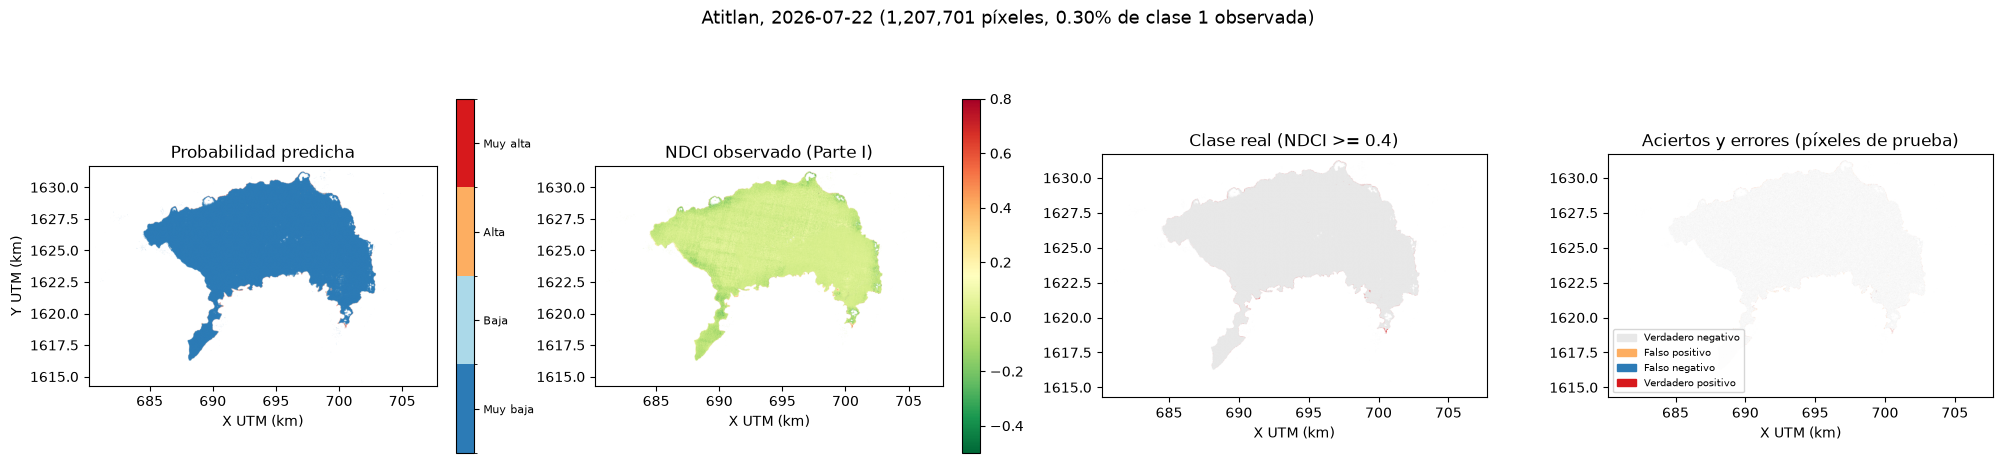

In [8]:
for fecha in fechas_sel['atitlan']:
    figura_mapas('atitlan', fecha)

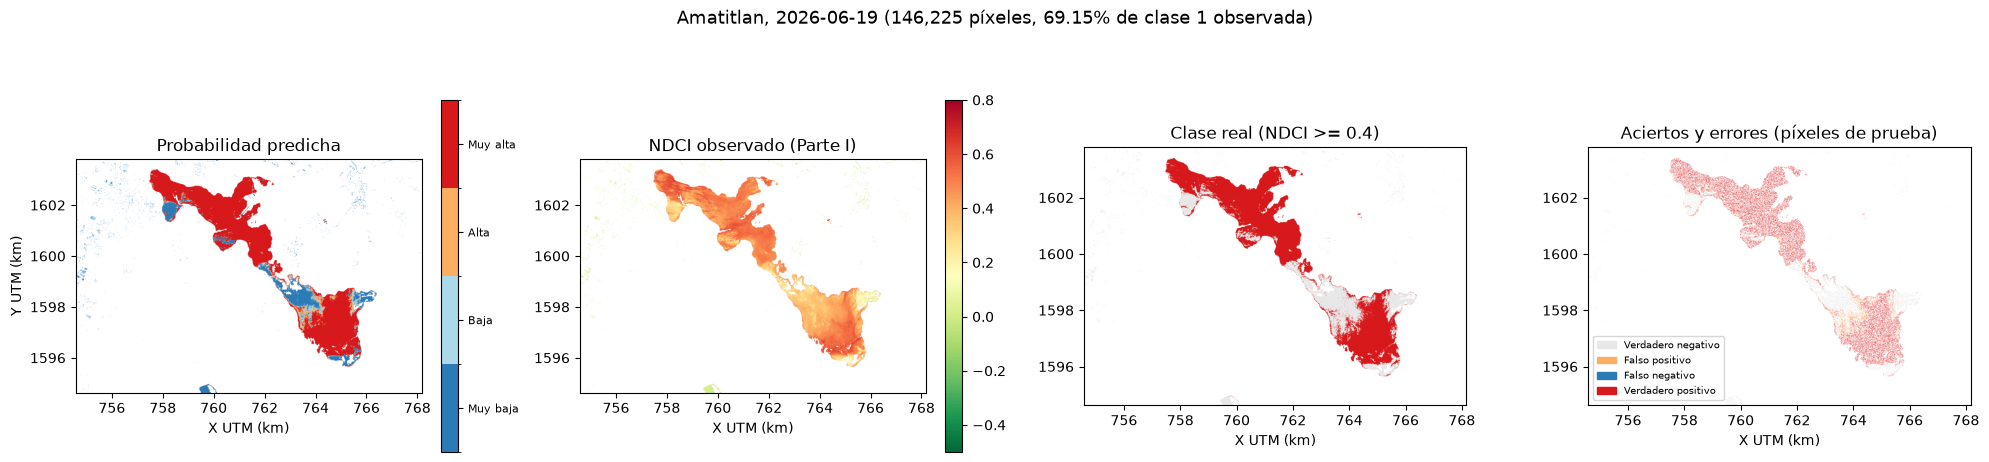

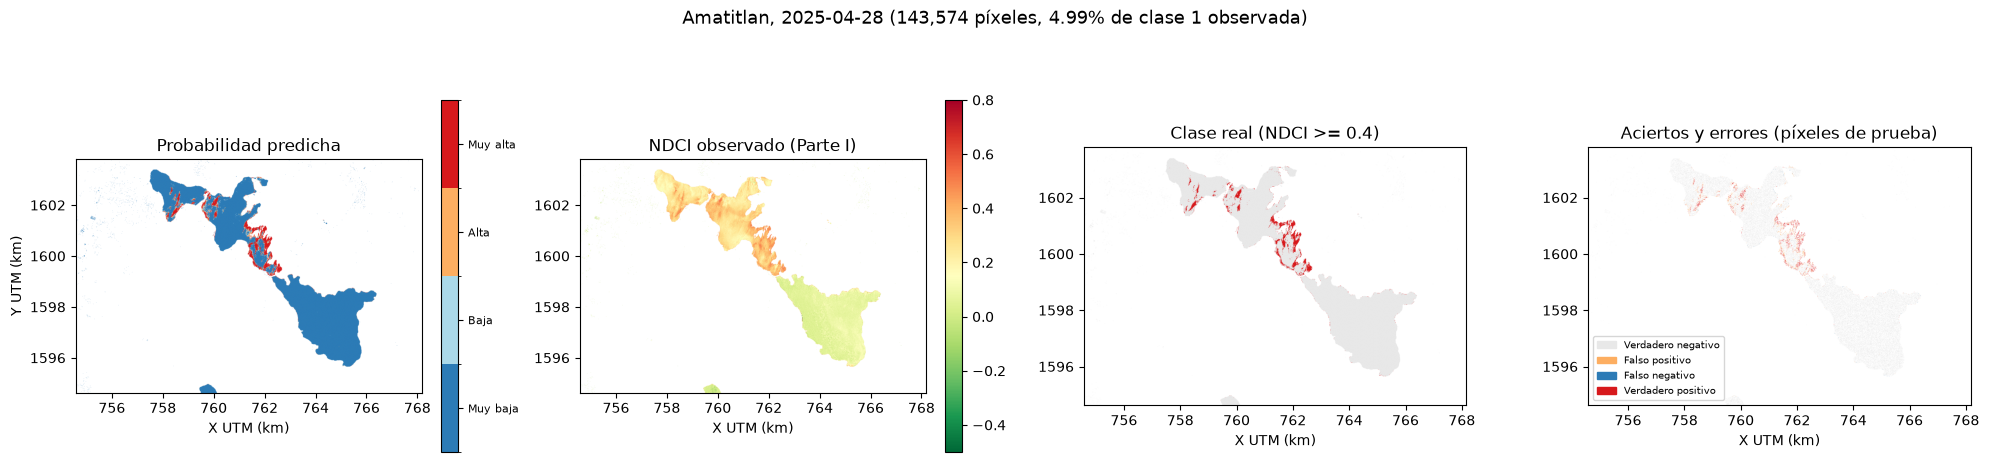

In [9]:
for fecha in fechas_sel['amatitlan']:
    figura_mapas('amatitlan', fecha)

**Lectura de los mapas (9.2 y 9.3).**

**Amatitlán, 2026-06-19**, la fecha de floración máxima con 69.15 % de píxeles positivos: el mapa de probabilidad reproduce casi exactamente la geometría del NDCI observado. La cuenca ancha del sureste y el brazo noroccidental aparecen en rojo, es decir probabilidad muy alta, y las zonas que el NDCI deja en amarillo quedan en azul. El panel de errores es casi todo rojo, verdaderos positivos, con pocos puntos dispersos.

**Amatitlán, 2025-04-28**, fecha típica con 4.99 % de positivos: el modelo acierta la localización de los parches, más pequeños y concentrados, aunque marca algo más de área de la que el NDCI confirma.

**Atitlán, 2025-01-18**, con 16.46 % de positivos: es la fecha que los notebooks anteriores señalaron como probable artefacto, y se nota en el mapa. La cobertura es parcial, 301,582 píxeles frente a más de 1.2 millones en otras fechas por el enmascarado de nubes, y tanto el NDCI como la predicción tienen aspecto de sal y pimienta, con píxeles positivos y negativos alternándose sin formar manchas continuas. Una floración real no se ve así, se ve como en Amatitlán, en parches conexos. La zona occidental sí aparece en azul sólido, coherente con los valores fuertemente negativos del NDCI allí. El modelo reproduce fielmente el patrón moteado, lo que confirma que aprendió el artefacto en lugar de una floración.

**Atitlán, 2026-07-22**, fecha típica con 0.30 % de positivos: el lago entero queda en probabilidad muy baja, con apenas unos píxeles marcados cerca de la orilla suroriental. El modelo no inventa floraciones donde no las hay, que es el comportamiento deseable.

## 5. Comparación con los mapas de la Parte I (9.5)

En cada figura, el segundo panel es el NDCI observado, que es la base de los mapas de cianobacteria de la Parte I, y el tercero es la clase real derivada del corte NDCI >= 0.4. Comparar el primer panel con esos dos permite ver si el modelo reproduce la geografía de la floración o solo su magnitud global.

In [10]:
# Correlación espacial entre la probabilidad predicha y el NDCI observado, por fecha
filas = []
for lago in ['atitlan', 'amatitlan']:
    for fecha, sub in mapa[mapa['lago'] == lago].groupby('fecha'):
        sub_t = sub[sub['en_prueba']]
        filas.append({
            'lago': lago,
            'fecha': pd.Timestamp(fecha).date(),
            'px prueba': len(sub_t),
            '% clase 1 real': 100 * sub_t['y_real'].mean(),
            '% predicho alta': 100 * (sub_t['prob'] >= 0.5).mean(),
            'corr prob-NDCI': np.corrcoef(sub_t['prob'].values, sub_t['NDCI'].values)[0, 1],
        })

df_fechas = pd.DataFrame(filas)
print('Comparación por fecha (solo píxeles de prueba):')
print(df_fechas.round(3).to_string(index=False))

Comparación por fecha (solo píxeles de prueba):
     lago      fecha  px prueba  % clase 1 real  % predicho alta  corr prob-NDCI
  atitlan 2025-01-18      90412          16.376           40.839           0.673
  atitlan 2025-04-13     368065           0.184            0.599           0.318
  atitlan 2025-05-13     368463           0.189            0.416           0.282
  atitlan 2025-07-17     360099           0.346            0.715           0.265
  atitlan 2025-11-21     306137           3.235            8.044           0.477
  atitlan 2025-12-29     339856           1.010            1.934           0.324
  atitlan 2026-02-12     289077           1.272            2.286           0.279
  atitlan 2026-03-24     366911           0.244            0.546           0.307
  atitlan 2026-04-13     366237           0.190            0.372           0.251
  atitlan 2026-04-28     366739           0.130            0.414           0.301
  atitlan 2026-07-22     362003           0.294            0.

### Qué tan parecido es el mapa predictivo al de la Parte I (9.5)

La correlación entre la probabilidad predicha y el NDCI observado, calculada solo sobre píxeles de prueba, varía bastante según la fecha y el lago:

- En **Amatitlán** va de 0.274 a 0.819, y las correlaciones más altas coinciden con las fechas de mayor floración (0.819 el 2026-06-19 y 0.733 el 2026-04-28). Cuando hay floración extensa, el mapa predictivo reproduce bien el mapa de NDCI.
- En **Atitlán** va de 0.251 a 0.673, y solo supera 0.45 en las dos fechas con más positivos (2025-01-18 y 2025-11-21). En las fechas tranquilas baja a 0.25 o 0.30, porque el NDCI varía poco y casi todo el lago es clase 0, así que no hay contraste espacial que reproducir.

El área marcada como alta presencia también es informativa. El modelo **sobreestima el área en casi todas las fechas**: en Atitlán predice 40.84 % de área positiva el 2025-01-18 frente a 16.38 % real, y en las fechas tranquilas predice del doble al triple del área real (0.60 % frente a 0.18 % el 2025-04-13). En Amatitlán la sobreestimación es menor y en una fecha incluso predice menos área de la real (0.71 % frente a 0.89 % el 2026-02-07). Esta sobreestimación es consecuencia directa de `class_weight='balanced'`, que penaliza más los falsos negativos, y es el comportamiento buscado desde el punto de vista ambiental.

## 6. Zonas bien detectadas, falsos positivos y falsos negativos (9.6)

In [11]:
prueba = mapa[mapa['en_prueba']].copy()
prueba['pred'] = (prueba['prob'] >= 0.5).astype(int)
prueba['tipo'] = np.where((prueba['y_real'] == 0) & (prueba['pred'] == 0), 'TN',
                 np.where((prueba['y_real'] == 0) & (prueba['pred'] == 1), 'FP',
                 np.where((prueba['y_real'] == 1) & (prueba['pred'] == 0), 'FN', 'TP')))

resumen_tipos = prueba.groupby(['lago', 'tipo']).size().unstack(fill_value=0)
resumen_tipos['Recall'] = resumen_tipos['TP'] / (resumen_tipos['TP'] + resumen_tipos['FN'])
resumen_tipos['Precision'] = resumen_tipos['TP'] / (resumen_tipos['TP'] + resumen_tipos['FP'])
print('Aciertos y errores por lago (conjunto de prueba):')
print(resumen_tipos.round(4).to_string())

Aciertos y errores por lago (conjunto de prueba):
tipo         FN     FP       TN     TP  Recall  Precision
lago                                                     
amatitlan  1833  16433   401228  50921  0.9653     0.7560
atitlan    6292  56933  3489493  31281  0.8325     0.3546


In [12]:
# ¿Los errores se concentran cerca del umbral que define la etiqueta?
prueba['dist_umbral'] = (prueba['NDCI'] - 0.4).abs()

resumen_ndci = prueba.groupby('tipo')['NDCI'].agg(['mean', 'median', 'count'])
resumen_dist = prueba.groupby('tipo')['dist_umbral'].agg(['mean', 'median'])
print('NDCI observado según el tipo de resultado:')
print(resumen_ndci.round(4).to_string())
print()
print('Distancia absoluta al umbral NDCI = 0.4:')
print(resumen_dist.round(4).to_string())

cerca = prueba['dist_umbral'] < 0.05
print()
print(f'Píxeles con NDCI a menos de 0.05 del umbral: {cerca.sum():,} '
      f'({100*cerca.mean():.2f}% del conjunto de prueba)')
print('Composición de ese grupo:')
print((prueba.loc[cerca, 'tipo'].value_counts(normalize=True) * 100).round(2).to_string())
print()
print('Composición del resto:')
print((prueba.loc[~cerca, 'tipo'].value_counts(normalize=True) * 100).round(2).to_string())

NDCI observado según el tipo de resultado:
        mean  median    count
tipo                         
FN    0.4893  0.4563     8125
FP    0.1288  0.2068    73366
TN   -0.0046 -0.0032  3890721
TP    0.5399  0.4966    82202

Distancia absoluta al umbral NDCI = 0.4:
        mean  median
tipo                
FN    0.0893  0.0563
FP    0.2712  0.1932
TN    0.4046  0.4032
TP    0.1399  0.0966

Píxeles con NDCI a menos de 0.05 del umbral: 68,345 (1.69% del conjunto de prueba)
Composición de ese grupo:
tipo
TP    34.96
TN    34.49
FP    25.12
FN     5.43

Composición del resto:


tipo
TN    97.02
TP     1.46
FP     1.41
FN     0.11


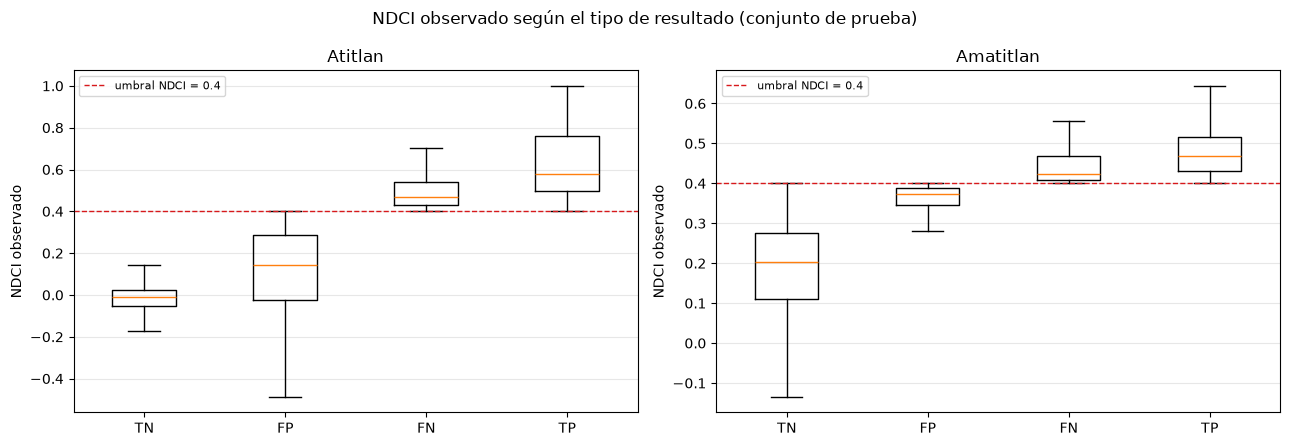

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, lago in zip(axes, ['atitlan', 'amatitlan']):
    sub = prueba[prueba['lago'] == lago]
    datos = [sub.loc[sub['tipo'] == t, 'NDCI'].values for t in ['TN', 'FP', 'FN', 'TP']]
    ax.boxplot(datos, tick_labels=['TN', 'FP', 'FN', 'TP'], showfliers=False)
    ax.axhline(0.4, color='#d7191c', linestyle='--', linewidth=1, label='umbral NDCI = 0.4')
    ax.set_title(f'{lago.capitalize()}')
    ax.set_ylabel('NDCI observado')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('NDCI observado según el tipo de resultado (conjunto de prueba)', fontsize=12)
plt.tight_layout()
plt.show()

### Zonas bien detectadas, falsos positivos y falsos negativos (9.6)

Sobre los 4,054,414 píxeles de prueba:

| Lago | TP | FN | FP | Recall | Precision |
|---|---|---|---|---|---|
| Amatitlán | 50,921 | 1,833 | 16,433 | 0.9653 | 0.7560 |
| Atitlán | 31,281 | 6,292 | 56,933 | 0.8325 | 0.3546 |

El desempeño es claramente mejor en Amatitlán: detecta el 96.5 % de las floraciones reales y tres de cada cuatro alertas son correctas. En Atitlán detecta el 83.2 %, pero solo una de cada tres alertas es correcta, casi el doble de falsos positivos que de verdaderos positivos.

**Los errores se concentran junto al umbral que define la etiqueta.** El NDCI medio de los falsos negativos es 0.4893 y su mediana 0.4563, es decir justo por encima del corte de 0.4, mientras que los verdaderos positivos tienen NDCI medio 0.5399. Los falsos positivos tienen NDCI medio 0.1288, muy por encima del -0.0046 de los verdaderos negativos. El modelo no se equivoca en píxeles claramente limpios ni en floraciones intensas, se equivoca en la franja de transición.

El dato más claro es este: entre los píxeles con NDCI a menos de 0.05 del umbral (68,345 píxeles, el 1.69 % del conjunto de prueba), el 25.12 % son falsos positivos y el 5.43 % falsos negativos, frente a 1.41 % y 0.11 % en el resto. Una franja que representa menos del 2 % de los datos concentra buena parte del error. Es un resultado esperable y hasta cierto punto tranquilizador: refleja que el corte NDCI >= 0.4 es una frontera arbitraria sobre una variable continua, y que un píxel con NDCI 0.38 y otro con 0.42 son prácticamente iguales aunque reciban etiquetas distintas.

## 7. Regiones donde el modelo tiene mayor dificultad (9.7)

Para ver si los errores tienen un patrón espacial y no están repartidos al azar, se agrupan los píxeles de prueba en bloques de 1 km por 1 km, el mismo tamaño usado en la validación espacial del notebook 06, y se calcula en cada bloque la tasa de falsos negativos y de falsos positivos.

In [14]:
TAM_BLOQUE = 1000  # metros

prueba['bx'] = ((prueba['lon'] - prueba.groupby('lago')['lon'].transform('min')) // TAM_BLOQUE).astype(int)
prueba['by'] = ((prueba['lat'] - prueba.groupby('lago')['lat'].transform('min')) // TAM_BLOQUE).astype(int)

bloques = prueba.groupby(['lago', 'bx', 'by']).apply(
    lambda g: pd.Series({
        'n': len(g),
        'positivos': (g['y_real'] == 1).sum(),
        'FN': (g['tipo'] == 'FN').sum(),
        'FP': (g['tipo'] == 'FP').sum(),
    }), include_groups=False
).reset_index()

bloques['tasa_FN'] = np.where(bloques['positivos'] > 0, bloques['FN'] / bloques['positivos'], np.nan)
bloques['tasa_FP'] = bloques['FP'] / (bloques['n'] - bloques['positivos']).replace(0, np.nan)

for lago in ['atitlan', 'amatitlan']:
    b = bloques[bloques['lago'] == lago]
    con_pos = b[b['positivos'] > 0]
    print(f'{lago.capitalize()}: {len(b)} bloques de 1 km, {len(con_pos)} con al menos un positivo real')
    if len(con_pos):
        print(f'  tasa de FN por bloque: media {con_pos["tasa_FN"].mean():.3f}, '
              f'mediana {con_pos["tasa_FN"].median():.3f}, '
              f'bloques con tasa FN > 0.5: {(con_pos["tasa_FN"] > 0.5).sum()}')
    print(f'  tasa de FP por bloque: media {b["tasa_FP"].mean():.4f}, '
          f'máxima {b["tasa_FP"].max():.4f}')

Atitlan: 265 bloques de 1 km, 175 con al menos un positivo real
  tasa de FN por bloque: media 0.221, mediana 0.181, bloques con tasa FN > 0.5: 10
  tasa de FP por bloque: media 0.0229, máxima 0.4000
Amatitlan: 110 bloques de 1 km, 44 con al menos un positivo real
  tasa de FN por bloque: media 0.197, mediana 0.063, bloques con tasa FN > 0.5: 5
  tasa de FP por bloque: media 0.0197, máxima 0.2593


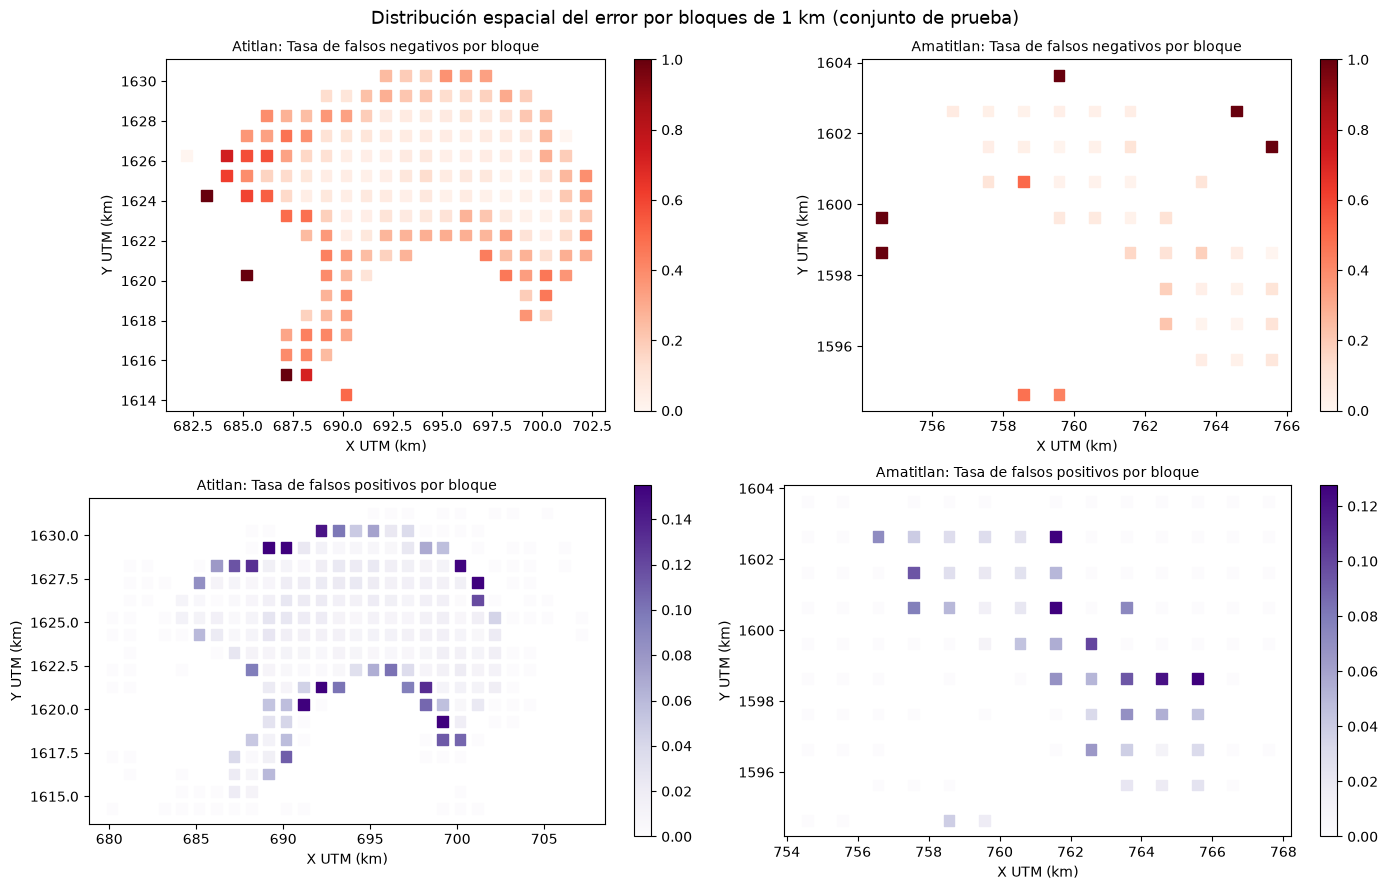

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for j, lago in enumerate(['atitlan', 'amatitlan']):
    b = bloques[bloques['lago'] == lago]
    x0, y0, _, _ = limites[lago]
    for i, (col, titulo, cmap) in enumerate([
            ('tasa_FN', 'Tasa de falsos negativos por bloque', 'Reds'),
            ('tasa_FP', 'Tasa de falsos positivos por bloque', 'Purples')]):
        ax = axes[i, j]
        sc = ax.scatter((x0 + b['bx']*TAM_BLOQUE)/1000, (y0 + b['by']*TAM_BLOQUE)/1000,
                        c=b[col], cmap=cmap, s=60, marker='s',
                        vmin=0, vmax=1 if col == 'tasa_FN' else b['tasa_FP'].quantile(0.98))
        ax.set_title(f'{lago.capitalize()}: {titulo}', fontsize=10)
        ax.set_xlabel('X UTM (km)')
        ax.set_ylabel('Y UTM (km)')
        ax.set_aspect('equal')
        fig.colorbar(sc, ax=ax, fraction=0.046)

plt.suptitle('Distribución espacial del error por bloques de 1 km (conjunto de prueba)', fontsize=13)
plt.tight_layout()
plt.savefig('./data/figuras/predictivos/error_por_bloque.png', dpi=110)
plt.show()

In [16]:
# ¿Los errores dependen de la posición dentro del lago?
prueba['dist_centro'] = X['dist_centro_lago'].values[prueba.index]

resumen_dist_centro = prueba.groupby(['lago', 'tipo'])['dist_centro'].mean().unstack().round(0)
print('Distancia media al centro del lago (metros) según el tipo de resultado:')
print(resumen_dist_centro.to_string())

# Tasa de FN por anillo de distancia
prueba['anillo'] = pd.qcut(prueba['dist_centro'], 5, labels=['muy cerca', 'cerca', 'medio', 'lejos', 'orilla'])
tasa_anillo = prueba[prueba['y_real'] == 1].groupby(['lago', 'anillo'], observed=True)['tipo'].apply(
    lambda s: (s == 'FN').mean())
print()
print('Tasa de falsos negativos por anillo de distancia al centro:')
print(tasa_anillo.round(4).to_string())

Distancia media al centro del lago (metros) según el tipo de resultado:
tipo           FN      FP      TN      TP
lago                                     
amatitlan  2971.0  2794.0  3070.0  3042.0
atitlan    6118.0  4765.0  4724.0  4804.0

Tasa de falsos negativos por anillo de distancia al centro:
lago       anillo   
amatitlan  muy cerca    0.0435
           cerca        0.0217
           medio        0.0371
           lejos        0.0575
           orilla       1.0000
atitlan    muy cerca    0.0603
           cerca        0.1110
           medio        0.1130
           lejos        0.1858
           orilla       0.2831


### Regiones donde el modelo tiene más dificultad (9.7)

Sí existe un patrón espacial claro y es el mismo en los dos lagos: **los errores se concentran en la periferia**.

- En **Atitlán** la tasa de falsos negativos crece de forma monótona del centro hacia la orilla: 6.0 %, 11.1 %, 11.3 %, 18.6 % y 28.3 % en el anillo de la orilla. Casi una de cada tres floraciones de la franja costera pasa desapercibida. La distancia media al centro de los falsos negativos es de 6,118 m, muy por encima de los 4,804 m de los verdaderos positivos.
- En **Amatitlán** el gradiente es mucho más débil, de 4.4 % a 5.8 % entre los cuatro primeros anillos, y la distancia media al centro apenas distingue entre tipos de error. El anillo de orilla marca 100 % de falsos negativos, pero contiene solo 4 píxeles positivos, así que ese valor no es representativo.

El mapa por bloques de 1 km confirma la lectura: en Atitlán los bloques con tasa alta de falsos negativos forman un anillo alrededor del perímetro del lago, sobre todo en el borde occidental y en las bahías del sur, mientras que los bloques interiores tienen tasas cercanas a cero. Los falsos positivos siguen un patrón parecido, concentrados en la orilla norte y noreste. De los 175 bloques de Atitlán con al menos un positivo real, 10 superan el 50 % de falsos negativos; en Amatitlán son 5 de 44.

**Por qué ocurre.** En la orilla, un píxel de 10 metros mezcla agua con vegetación acuática, sedimento en suspensión y suelo, así que la firma espectral deja de ser la del agua abierta. Además la máscara de agua por NDWI es menos fiable ahí y el propio NDCI se vuelve inestable. Es una limitación de la resolución espacial y del enmascarado, no del clasificador.

**Implicación práctica.** El mapa predictivo es confiable en aguas abiertas y debe leerse con cautela en la franja costera, que es justamente donde están las playas y los usos recreativos. Para un sistema operativo de alerta convendría bajar el umbral de decisión en los bloques costeros, o excluir una franja de borde y cubrirla con muestreo en campo.

## 8. Guardado de resultados

In [17]:
mapa[['lago', 'fecha', 'lon', 'lat', 'prob', 'y_real', 'en_prueba']].to_parquet(
    './data/probabilidades_todas.parquet', index=False)
bloques.to_csv('./data/error_por_bloque.csv', index=False)
df_fechas.to_csv('./data/comparacion_mapas_por_fecha.csv', index=False)

print('Guardado:')
print('  ./data/probabilidades_todas.parquet')
print('  ./data/error_por_bloque.csv')
print('  ./data/comparacion_mapas_por_fecha.csv')
print('  ./data/figuras/predictivos/ (mapas en PNG)')

Guardado:
  ./data/probabilidades_todas.parquet
  ./data/error_por_bloque.csv
  ./data/comparacion_mapas_por_fecha.csv
  ./data/figuras/predictivos/ (mapas en PNG)
